# 1. Business Understanding

### Aanleiding
Dit project is een samenwerking tussen Isala en Windesheim in het kader van de [PhysioNet/Computing in Cardiology Challenge 2019](https://physionet.org/content/challenge-2019/). De challenge draait om het vroegtijdig detecteren van sepsis bij patiënten op de intensive care, aan de hand van patiënteninformatie en uurlijkse klinische metingen.

Sepsis is een levensbedreigende orgaandisfunctie als gevolg van een ontregelde immuunrespons op een infectie. Vroege herkenning is cruciaal: elke uur vertraging in behandeling verhoogt de mortaliteit. Tegelijkertijd wil je niet te veel valse alarmen genereren, want elk alarm leidt tot extra diagnostiek en belasting van het zorgpersoneel.

### Business Vraag
Is het haalbaar om met historische IC-data betrouwbaar en eerlijk sepsis zes uur voor de daadwerkelijke diagnose te voorspellen, onafhankelijk van het geslacht of de leeftijd van de patiënt? Zodat IC-artsen sneller kunnen ingrijpen, om de overlevingskans van patiënten te verhogen. 

### Datavragen (Data mining goals)
1. Welk voorspellend model behaalt de hoogste Utility Score bij het signaleren van sepsis zes uur vóór de klinische diagnose?

2. In hoeverre presteert dit algoritme eerlijk voor verschillende leeftijds- en geslachtsgroepen?

3. Welke features zijn het belangrijkst bij het voorspellen van sepsis zes uur vóór de klinische diagnose?

### Maatschappelijke en organisatorische Context
In Nederland overlijden jaarlijks circa 10.000 mensen aan sepsis, op een totaal van 60.000 gevallen. De maatschappelijke kosten worden geschat op 3,8 tot 6,5 miljard euro per jaar [2]. Sepsis is daarmee de voornaamste doodsoorzaak op de intensive care. Vroegere detectie vermindert niet alleen sterfte, maar ook langdurige schade: 75% van de overlevenden houdt fysieke, mentale of cognitieve klachten [4].

### Juridische Implicaties
De gebruikte dataset is geanonimiseerd en valt daarmee buiten de directe werking van de AVG. Mocht het model in de toekomst worden ingezet op echte Isala-patiëntdata, dan is artikel 9 AVG van toepassing omdat medische gegevens bijzondere persoonsgegevens zijn.
Onder de EU AI Act [6] wordt een sepsisvoorspellingsmodel geclassificeerd als een hoogrisicosysteem. Het model wordt uitsluitend ingezet als beslissingsondersteuning; de behandelende arts blijft eindverantwoordelijk voor diagnose en behandeling.
Dit heeft geen impact op onze huidige werkwijze, aangezien wij werken met geanonimiseerde data. Dit betekent dat ons model in de toekomst ook zal kunnen werken met data die geanonimiseerd is, zonder prestatieverlies.

### Stakeholders
Opdrachtgevers (Isala): Jorik Slotman (portfoliomanager Data & AI) en Remco Poelarends (PhD-kandidaat Nucleaire geneeskunde) 

Begeleider (Windesheim): dr. ir. Gido Hakvoort (Associate Lector ICT-innovaties in de Zorg) 

Eindgebruikers: zorgpersoneel en patiënten van Isala 

Belang: betrouwbare beslissingsondersteuning, hogere overlevingskans, privacybescherming en een eerlijk algoritme dat geen ongelijkheid introduceert op basis van geslacht of leeftijd.


## 2. Data Understanding



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import time
warnings.filterwarnings('ignore')
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    roc_auc_score, average_precision_score, f1_score, precision_score, recall_score
)
import lightgbm as lgb
from lightgbm import LGBMRegressor

In [ ]:
train_data = pd.read_csv("data/train_data.csv")
test_data = pd.read_csv("data/test_data.csv")

In [3]:
train_data.head()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


Er zijn heel veel NaN waarden, vooral bij labwaarden. Er zijn veel verschillende kolomtitels. Een patient kan meerdere rijen hebben.

In [4]:
test_data.head()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,Patient_ID
0,0,0,88.5,88.0,38.39,NaN,98.0,NaN,17.0,NaN,...,14.6,NaN,254.0,69.82,1,NaN,NaN,-0.01,3,2136
1,1,1,98.5,94.0,NaN,NaN,100.0,NaN,18.5,NaN,...,14.6,NaN,NaN,69.82,1,NaN,NaN,-0.01,4,2136
2,2,2,102.0,100.0,NaN,NaN,65.0,NaN,20.0,NaN,...,NaN,NaN,NaN,69.82,1,NaN,NaN,-0.01,5,2136
3,3,3,102.0,100.0,38.44,NaN,55.0,NaN,19.0,NaN,...,NaN,NaN,NaN,69.82,1,NaN,NaN,-0.01,6,2136
4,4,4,97.0,99.0,NaN,NaN,81.0,NaN,23.0,NaN,...,NaN,NaN,NaN,69.82,1,NaN,NaN,-0.01,7,2136


De testdata heeft dezelfde kolommen als traindata maar zonder het sepsislabel.

In [5]:
train_data.describe()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
count,1.399302e+06,1.399302e+06,1.261070e+06,1.216615e+06,474304.000000,1.195492e+06,1.225052e+06,961600.000000,1.184880e+06,52020.000000,...,9319.000000,83243.000000,1.399302e+06,1.399302e+06,848885.000000,848885.000000,1.399294e+06,1.399302e+06,1.399302e+06,1.399302e+06
mean,2.551103e+01,2.551103e+01,8.459206e+01,9.719306e+01,36.977555,1.237281e+02,8.239274e+01,63.795128,1.873619e+01,32.925865,...,287.729520,195.940093,6.199812e+01,5.604073e-01,0.496395,0.503605,-5.614702e+01,2.700756e+01,1.821051e-02,5.917730e+04
std,2.884830e+01,2.884830e+01,1.734384e+01,2.945582e+00,0.773453,2.320404e+01,1.634168e+01,13.945080,5.098782e+00,7.931398,...,153.426372,104.158390,1.639975e+01,4.963377e-01,0.499987,0.499987,1.656790e+02,2.894534e+01,1.337120e-01,5.022381e+04
min,0.000000e+00,0.000000e+00,2.000000e+01,2.000000e+01,20.900000,2.000000e+01,2.000000e+01,20.000000,1.000000e+00,10.000000,...,34.000000,1.000000,1.400000e+01,0.000000e+00,0.000000,0.000000,-5.366860e+03,1.000000e+00,0.000000e+00,1.000000e+00
25%,9.000000e+00,9.000000e+00,7.200000e+01,9.600000e+01,36.500000,1.070000e+02,7.100000e+01,54.000000,1.500000e+01,28.000000,...,184.000000,126.000000,5.172000e+01,0.000000e+00,0.000000,0.000000,-4.675000e+01,1.100000e+01,0.000000e+00,9.996000e+03
50%,1.900000e+01,1.900000e+01,8.350000e+01,9.800000e+01,37.000000,1.210000e+02,8.000000e+01,62.000000,1.800000e+01,33.000000,...,251.000000,180.000000,6.400000e+01,1.000000e+00,0.000000,1.000000,-6.030000e+00,2.100000e+01,0.000000e+00,1.996200e+04
75%,3.300000e+01,3.300000e+01,9.600000e+01,9.950000e+01,37.500000,1.380000e+02,9.200000e+01,72.000000,2.150000e+01,38.000000,...,349.000000,244.000000,7.400000e+01,1.000000e+00,1.000000,1.000000,-4.000000e-02,3.400000e+01,0.000000e+00,1.098270e+05
max,3.350000e+02,3.350000e+02,2.800000e+02,1.000000e+02,50.000000,3.000000e+02,3.000000e+02,300.000000,1.000000e+02,100.000000,...,1760.000000,2322.000000,1.000000e+02,1.000000e+00,1.000000,1.000000,2.399000e+01,3.360000e+02,1.000000e+00,1.200000e+05


Er zijn veel missende waarden. De gender is 0 of 1. Sepsis label is 0 of 1. De mean van sepsislabel is 0.018 wat betekent dat er een klasse imbalans is. Er zijn ook meer mannen dan vrouwen in de dataset. 1.8% van de patienten heeft sepsis.

In [6]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 152908 entries, 0 to 152907
Data columns (total 43 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        152908 non-null  int64  
 1   Hour              152908 non-null  int64  
 2   HR                137741 non-null  float64
 3   O2Sat             132859 non-null  float64
 4   Temp              50922 non-null   float64
 5   SBP               130453 non-null  float64
 6   MAP               133888 non-null  float64
 7   DBP               104056 non-null  float64
 8   Resp              128995 non-null  float64
 9   EtCO2             5616 non-null    float64
 10  BaseExcess        7801 non-null    float64
 11  HCO3              6219 non-null    float64
 12  FiO2              12114 non-null   float64
 13  pH                10002 non-null   float64
 14  PaCO2             8017 non-null    float64
 15  SaO2              5152 non-null    float64
 16  AST               2379 non-null

In [7]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1399302 entries, 0 to 1399301
Data columns (total 44 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1399302 non-null  int64  
 1   Hour              1399302 non-null  int64  
 2   HR                1261070 non-null  float64
 3   O2Sat             1216615 non-null  float64
 4   Temp              474304 non-null   float64
 5   SBP               1195492 non-null  float64
 6   MAP               1225052 non-null  float64
 7   DBP               961600 non-null   float64
 8   Resp              1184880 non-null  float64
 9   EtCO2             52020 non-null    float64
 10  BaseExcess        76344 non-null    float64
 11  HCO3              58809 non-null    float64
 12  FiO2              117251 non-null   float64
 13  pH                97571 non-null    float64
 14  PaCO2             78284 non-null    float64
 15  SaO2              48409 non-null    float64
 16  AST        

Er zijn veel non-null waardes, dit komt waarschijnlijk omdat bloedtesten lang niet elk uur worden gedaan, alleen wanneer nodig.

### Bias check, man en vrouw verdeling

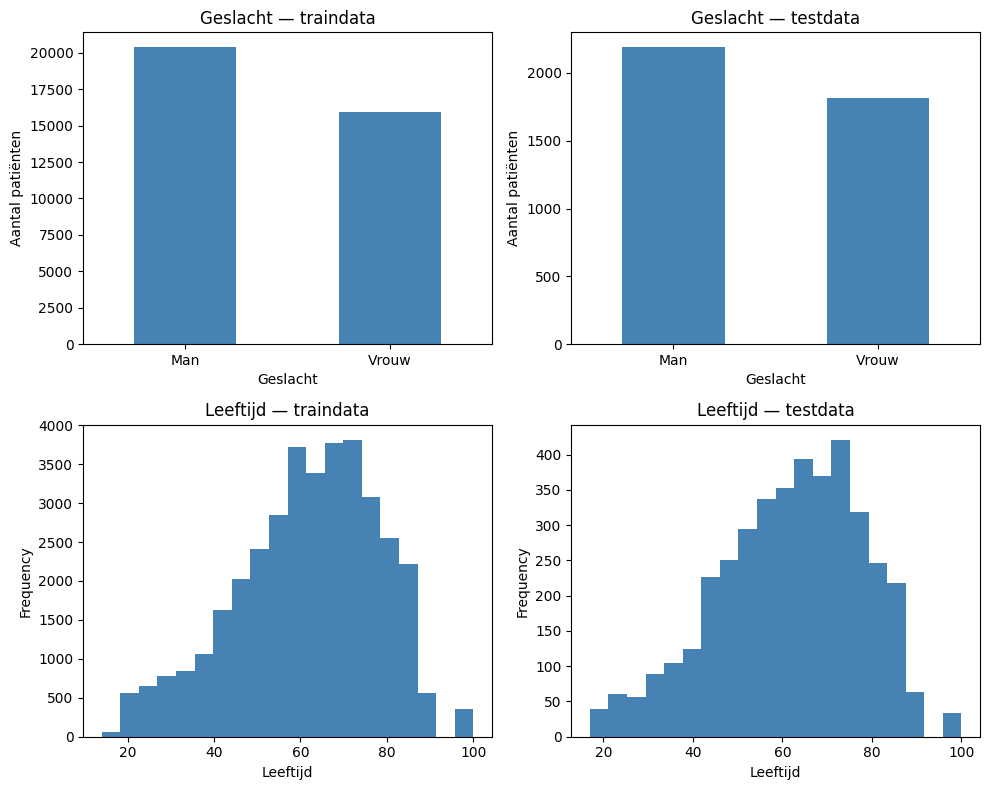

In [8]:
# In de data staat Gender als 0 (vrouw) of 1 (man)
# We vervangen die nummers door woorden, dat leest makkelijker
patienten_train = train_data.groupby('Patient_ID').agg(
    Geslacht=('Gender', 'first'),
    Leeftijd=('Age', 'first')
)
patienten_train['Geslacht'] = patienten_train['Geslacht'].map({0: 'Vrouw', 1: 'Man'})

patienten_test = test_data.groupby('Patient_ID').agg(
    Geslacht=('Gender', 'first'),
    Leeftijd=('Age', 'first')
)
patienten_test['Geslacht'] = patienten_test['Geslacht'].map({0: 'Vrouw', 1: 'Man'})

# Maak vier grafieken: geslacht en leeftijd voor train en test
fig, assen = plt.subplots(2, 2, figsize=(10, 8))

# Geslachtsverdeling traindata
patienten_train['Geslacht'].value_counts().plot(kind='bar', ax=assen[0, 0], color='steelblue', rot=0)
assen[0, 0].set_title('Geslacht — traindata')
assen[0, 0].set_ylabel('Aantal patiënten')

# Geslachtsverdeling testdata
patienten_test['Geslacht'].value_counts().plot(kind='bar', ax=assen[0, 1], color='steelblue', rot=0)
assen[0, 1].set_title('Geslacht — testdata')
assen[0, 1].set_ylabel('Aantal patiënten')

# Leeftijdsverdeling traindata
patienten_train['Leeftijd'].plot(kind='hist', ax=assen[1, 0], color='steelblue', bins=20)
assen[1, 0].set_title('Leeftijd — traindata')
assen[1, 0].set_xlabel('Leeftijd')

# Leeftijdsverdeling testdata
patienten_test['Leeftijd'].plot(kind='hist', ax=assen[1, 1], color='steelblue', bins=20)
assen[1, 1].set_title('Leeftijd — testdata')
assen[1, 1].set_xlabel('Leeftijd')

plt.tight_layout()
plt.show()

Mannen zijn overgerepresenteerd in de datasets, ook ligt de leeftijd hoog, wat logisch is want oudere mensen hebben meer gezondheidsproblemen. Dit zou effect kunnen hebben op de prestaties per demografie van het uiteindelijke model dat we op deze data ontwikkelen.

Laten we ook kijken naar de verdeling onder alleen sepsis patienten.

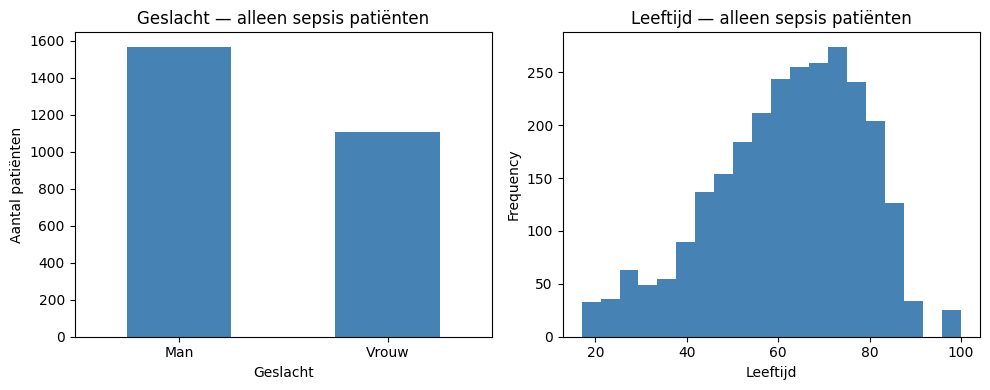

Sepsis patiënten: 2674
Geslacht
Man      1568
Vrouw    1106

Gemiddelde leeftijd: 62.0 jaar
Mediaan leeftijd:   64.0 jaar


In [27]:
# Selecteer alleen patiënten die ooit sepsis hebben gekregen
sepsis_patienten_ids = train_data.groupby('Patient_ID')['SepsisLabel'].max()
sepsis_patienten_ids = sepsis_patienten_ids[sepsis_patienten_ids == 1].index

patienten_sepsis = train_data[train_data['Patient_ID'].isin(sepsis_patienten_ids)].groupby('Patient_ID').agg(
    Geslacht=('Gender', 'first'),
    Leeftijd=('Age', 'first')
)
patienten_sepsis['Geslacht'] = patienten_sepsis['Geslacht'].map({0: 'Vrouw', 1: 'Man'})

fig, assen = plt.subplots(1, 2, figsize=(10, 4))

# Geslachtsverdeling sepsis patiënten
patienten_sepsis['Geslacht'].value_counts().plot(kind='bar', ax=assen[0], color='steelblue', rot=0)
assen[0].set_title('Geslacht — alleen sepsis patiënten')
assen[0].set_ylabel('Aantal patiënten')

# Leeftijdsverdeling sepsis patiënten
patienten_sepsis['Leeftijd'].plot(kind='hist', ax=assen[1], color='steelblue', bins=20)
assen[1].set_title('Leeftijd — alleen sepsis patiënten')
assen[1].set_xlabel('Leeftijd')

plt.tight_layout()
plt.show()

print(f"Sepsis patiënten: {len(patienten_sepsis)}")
print(patienten_sepsis['Geslacht'].value_counts().to_string())
print(f"\nGemiddelde leeftijd: {patienten_sepsis['Leeftijd'].mean():.1f} jaar")
print(f"Mediaan leeftijd:   {patienten_sepsis['Leeftijd'].median():.1f} jaar")

Van de 2674 patienten met sepsis is 58,6% man en 41,4% vrouw. Dit is schever dan de totale dataset waar 56,1% man is. De gemiddelde leeftijd van 62 jaar en de mediaan van 64 jaar komt overeen met die van de totale populatie. Die is 61,6 jaar. De verdelingen in de sepsis groep weerspiegelt dus de gehele dataset zonder grote afwijkingen.

Is er verschil tussen de leeftijdsgroepen?

In [ ]:
# Stap 1: Haal per patiënt de leeftijd op en of ze ooit sepsis hebben gehad
patienten = train_data.groupby('Patient_ID').agg(
    Leeftijd=('Age', 'first'),       # leeftijd (zelfde voor alle rijen per patiënt)
    Sepsis=('SepsisLabel', 'max')    # 1 als patiënt ooit sepsis had, anders 0
).reset_index()

# Stap 2: Verdeel patiënten in vijf leeftijdsgroepen
patienten['Leeftijdsgroep'] = pd.cut(
    patienten['Leeftijd'],
    bins=[0, 30, 50, 70, 80, 200],
    labels=['Jong (<30)', 'Volwassen (30–50)', 'Middel (50–70)', 'Oud (70–80)', 'Zeer oud (>80)']
)

# Stap 3: Tel per groep hoeveel patiënten er zijn en hoeveel sepsis hadden
overzicht = patienten.groupby('Leeftijdsgroep', observed=True).agg(
    Totaal=('Sepsis', 'count'),
    Met_sepsis=('Sepsis', 'sum')
).reset_index()

# Stap 4: Bereken het percentage met sepsis per groep
overzicht['Sepsis_%'] = overzicht['Met_sepsis'] / overzicht['Totaal'] * 100

print(overzicht.to_string(index=False))

# Stap 5: Maak twee grafieken naast elkaar
fig, assen = plt.subplots(1, 2, figsize=(10, 4))

overzicht.set_index('Leeftijdsgroep')['Totaal'].plot(
    kind='bar', ax=assen[0], color='steelblue', rot=0)
assen[0].set_title('Aantal patiënten per leeftijdsgroep')
assen[0].set_ylabel('Aantal patiënten')

overzicht.set_index('Leeftijdsgroep')['Sepsis_%'].plot(
    kind='bar', ax=assen[1], color='steelblue', rot=0)
assen[1].set_title('Sepsispercentage per leeftijdsgroep')
assen[1].set_ylabel('Sepsis (%)')

plt.tight_layout()
plt.show()

Er is een duidelijk verschil tussen de leeftijdsgroepen. Oudere patiënten (>70 jaar) hebben het hoogste sepsispercentage, gevolgd door de middelste groep (50–70 jaar). Jongere patiënten (<50 jaar) hebben de laagste hoeveelheid sepsis. Dit patroon is verwacht omdat een ouder en verzwakt immuunsysteem de kans op sepsis vergroot. De middelste leeftijdsgroep is ook de grootste in absolute aantallen. Dit heeft gevolgen voor het model. De meeste leerervaringen komen uit de middelste en oudste groep, en de presentatie van sepsis kan per leeftijdsgroep verschillen.

### Missende Waarden

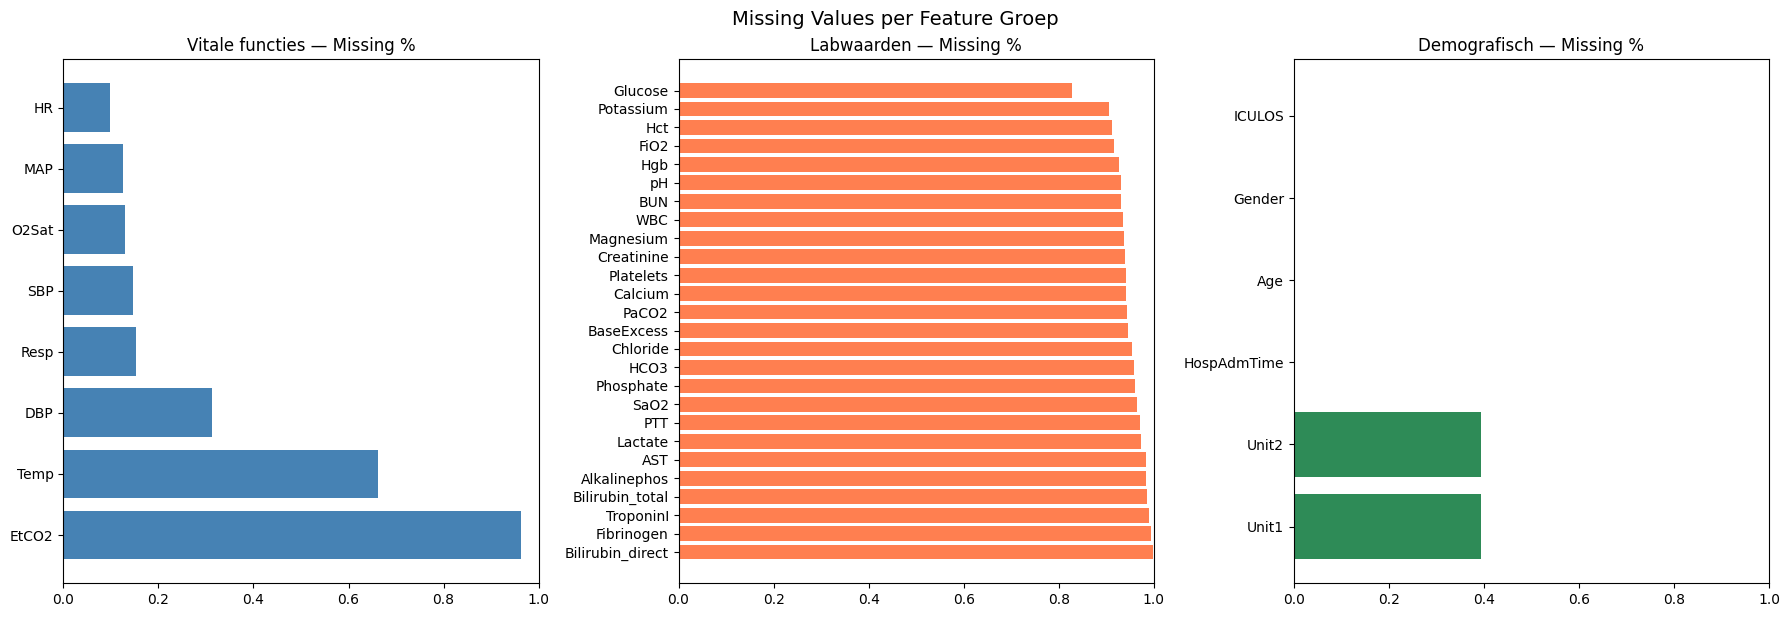

In [9]:
# Variabele groepen
VITAL_SIGNS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']
LAB_VALUES = ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
              'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
              'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
              'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
              'Fibrinogen', 'Platelets']
DEMOGRAPHICS = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']

# Missing values per variabele groepen 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

missing_vital = train_data[VITAL_SIGNS].isnull().mean().sort_values(ascending=False)
missing_lab = train_data[LAB_VALUES].isnull().mean().sort_values(ascending=False)
missing_demo = train_data[DEMOGRAPHICS].isnull().mean().sort_values(ascending=False)

axes[0].barh(missing_vital.index, missing_vital.values, color='steelblue')
axes[0].set_title('Vitale functies — Missing %')
axes[0].set_xlim(0, 1)

axes[1].barh(missing_lab.index, missing_lab.values, color='coral')
axes[1].set_title('Labwaarden — Missing %')
axes[1].set_xlim(0, 1)

axes[2].barh(missing_demo.index, missing_demo.values, color='seagreen')
axes[2].set_title('Demografisch — Missing %')
axes[2].set_xlim(0, 1)

plt.tight_layout()
plt.suptitle('Missing Values per Feature Groep', y=1.02, fontsize=14)
plt.show()

Temperatuur en EtCO2 missen veel, en van labwaarden bijna allemaal.

### Correlatie tussen variabelen en sepsis

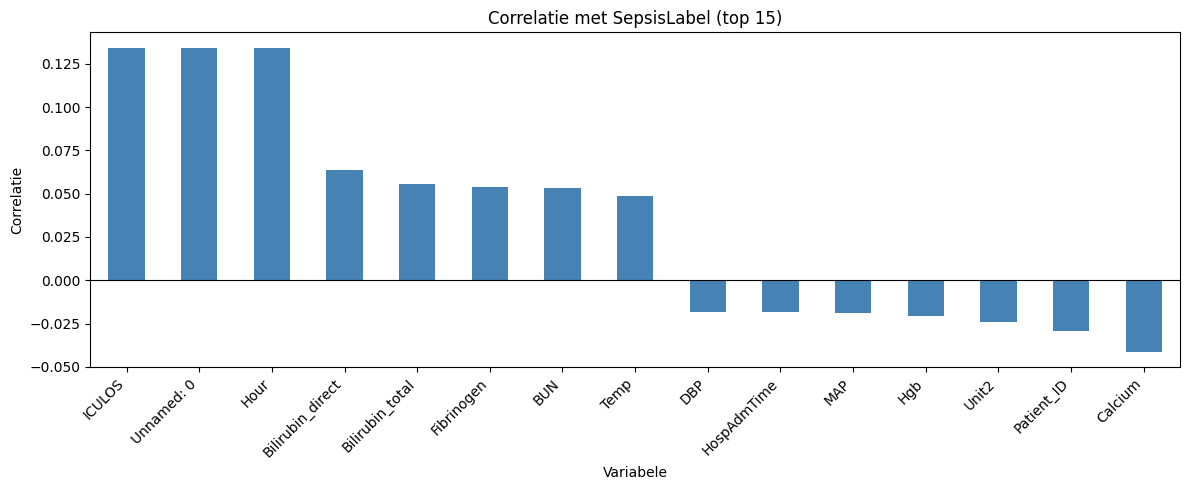

In [10]:
# Bereken de correlatie van elke variabele met SepsisLabel
# Een hogere waarde (dichter bij 1 of -1) = sterkere samenhang met sepsis
correlaties = train_data.corr()['SepsisLabel'].drop('SepsisLabel')

# Sorteer van sterkste naar zwakste correlatie
correlaties = correlaties.sort_values(ascending=False)

# Laat de top 15 sterkste correlaties zien (positief én negatief)
top_positief = correlaties.head(8)
top_negatief = correlaties.tail(7)
top15 = pd.concat([top_positief, top_negatief])

# Maak een staafdiagram
top15.plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.axhline(0, color='black', linewidth=0.8)  # lijn bij 0
plt.title('Correlatie met SepsisLabel (top 15)')
plt.ylabel('Correlatie')
plt.xlabel('Variabele')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Er is een hogere colleratie tussen ICULOS (Intensive Care Length Of Stay) en Hour (Hoelang de patient in het ziekenhuis is). 

### Klassenverdeling Sepsis

Patiënten met sepsis: 2674 van de 36336 (7.4%)

Gemiddeld aantal uur op de IC:
  Alle patiënten:       39 uur
  Patiënten met sepsis: 59 uur


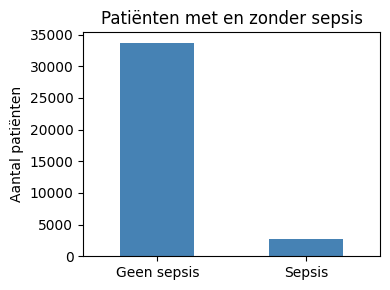

In [11]:
# Hoeveel patiënten hebben ooit sepsis gekregen?
patient_sepsis = train_data.groupby('Patient_ID')['SepsisLabel'].max()
aantal_sepsis = (patient_sepsis == 1).sum()
totaal_patienten = len(patient_sepsis)

print(f"Patiënten met sepsis: {aantal_sepsis} van de {totaal_patienten} ({aantal_sepsis / totaal_patienten * 100:.1f}%)")

# Hoe lang lagen patiënten gemiddeld op de IC? (in uren)
uren_per_patient = train_data.groupby('Patient_ID').size()

# Maak een apart lijstje van patiënten met sepsis
patienten_met_sepsis = patient_sepsis[patient_sepsis == 1].index

print(f"\nGemiddeld aantal uur op de IC:")
print(f"  Alle patiënten:       {uren_per_patient.mean():.0f} uur")
print(f"  Patiënten met sepsis: {uren_per_patient[patienten_met_sepsis].mean():.0f} uur")

# Grafiek: wel of geen sepsis
pd.Series({
    'Geen sepsis': totaal_patienten - aantal_sepsis,
    'Sepsis': aantal_sepsis
}).plot(kind='bar', color='steelblue', rot=0, figsize=(4, 3))
plt.title('Patiënten met en zonder sepsis')
plt.ylabel('Aantal patiënten')
plt.tight_layout()
plt.show()

Op basis van deze data als we een model maken die altijd geen sepsis voorspeld is de accuracy 90+ accuracy. Maar dan worden wel alle sepsisgevallen gemist.

### Correlatiematrix

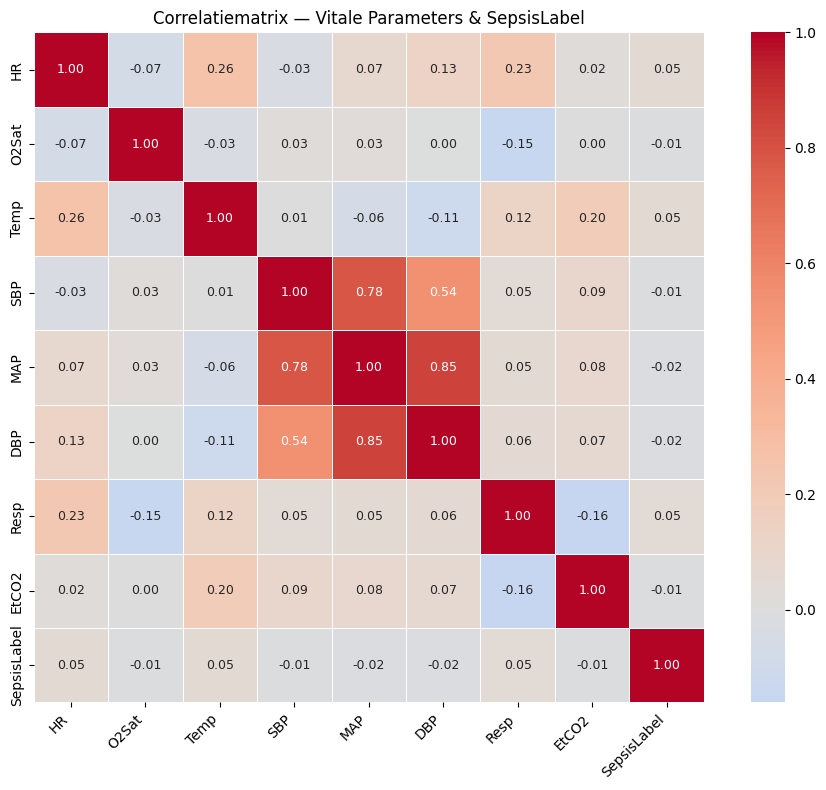

In [12]:
# Correlatiematrix van vitale parameters
corr_cols = VITAL_SIGNS + ['SepsisLabel']
corr_matrix = train_data[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('Correlatiematrix — Vitale Parameters & SepsisLabel')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Inzichten 

1. Er zijn meer mannen dan vrouwen aanwezig in beide datasets. 
2. Er is een hogere correlatie met ICULOS en sepsis.
3. Er zijn veel missende labwaarden.
4. Er is sprake van klasse inbalans.
5. De leeftijd is linksscheef verdeeld.
6. Er zijn geen features die sepsis goed voorspellen.
7. Er is multicollineariteit aanwezig tussen de vitale features.

### Vervolgstappen 

1. We nemen geslacht mee als feature en toetsen het later aan de biasanalyse.
2. We nemen ICULOS mee. Maar moeten wel kijken naar data leakage.
3. Imputatie toepassen om de waarden in te vullen. Ook misschien missendheid van bepaalde waarde gebruiken als een voorspeller
4.  Accuracy is geen bruikbare metric. We moeten class weighting toepassen en de utility score gebruiken.
5. De leeftijd is representatief voor de ICU.
6. Random Forest of Gradient Boosting model gebruiken omdat individuele correlaties laag zijn.
7. Feature engineering toepassen, testen wat goed werkt met deze data. 





## 3. Data Preparation

We hebben de beste data preperation technieken uit eerdere cycli gecombineerd in één functie. De voorbereiding bestaat uit negen stappen:

1. Voor 14 waarden (6 vitale parameters + 8 labwaarden) berekenen we per patiënt het rollend gemiddelde, de standaarddeviatie, het minimum en het maximum over meerdere tijdvensters. Dit geeft het model inzicht in trends en variabiliteit over de tijd.

2. Voor dezelfde 14 variabelen berekenen we de verandering ten opzichte van 1, 3 en 6 uur eerder. Zo kan het model plotse verslechteringen detecteren.

3. We berekenen vier medisch relevante verhoudingen: shock index (HR/SBP), polsdruk (SBP−DBP), MAP/DBP-ratio en BUN/creatinine-ratio.

4. Extra combinaties van vitale parameters: HR×Resp, HR/MAP, Temp×HR, Resp/O2Sat, en de trend van de shock index over 6 uur.

5. Voor elk van de 8 labwaarden houden we bij hoeveel uur er zijn verstreken sinds de laatste beschikbare meting. Een lang gemis kan klinisch relevant zijn.

6. Voor elke vitale parameter voegen we een binaire kolom toe (wel/niet gemeten dit uur), plus twee telkolommen voor het totaal aantal missende vitale parameters en labwaarden per rij.

7. We voegen `ICULOS²` en `log(ICULOS+1)` toe, zodat het model niet-lineaire verbanden met de verblijfsduur op de IC kan leren.

8. Voor HR, MAP, Resp en Temp sommeren we de absolute uur-op-uur-veranderingen over de gehele opname. Dit meet hoe instabiel een patiënt in totaal is geweest.

9. Na alle berekeningen vullen we ontbrekende waarden in de feature-kolommen aan met de laatste bekende waarde per patiënt. Het laatste gemeten labresultaat blijft geldig totdat er een nieuw resultaat is.

In [ ]:
from groepsnotebook_hulpfuncties import engineer_features
# drop onnodige kolommen
train_data = train_data.drop(columns=['Unnamed: 0'])
test_data = test_data.drop(columns=['Unnamed: 0']) 
# feature engineering (zie hulpfuncties.py voor details)
train_data_fe = engineer_features(train_data)
test_data_fe  = engineer_features(test_data)

print(f"train {train_data_fe.shape} \ntest {test_data_fe.shape}")

train (1399302, 284) 
test (152908, 283)


## 4. Modeling

### Best gevonden aanpak
We trainen drie modellen die elk een ander perspectief op de data hebben, en combineren ze daarna:

- Model A: binaire classifier op feature-engineered data (`scale_pos_weight=8`). Leert direct onderscheid maken tussen sepsis en niet-sepsis.
- Model B: regressiemodel op utility-labels. Per uur wordt bijgehouden hoe waardevol het voor de utility score is om nu alarm te slaan. Optimaliseert direct op de utility score.
- Model C: binaire classifier op de ruwe data zonder feature engineering. LightGBM verwerkt NaN-waarden zelf; de afwezigheid van een labmeting is hiermee zelf een feature.

De drie armen lopen bewust door elkaar heen: ze zien de data anders en maken fouten op verschillende patiënten. Dat maakt de combinatie/blend van hun uitkomsten zinvol: Optuna zoekt de gewichten en drempelwaarde die samen de utility maximaliseren.

In [14]:
from groepsnotebook_hulpfuncties import (
    split_train_val, compute_utility_labels, utility_score,
    train_binary, train_utility_reg, find_best_threshold,
    run_optuna_blend, apply_blend, EXCLUDE_COLS,
)

FE_FEATURE_COLS  = [c for c in train_data_fe.columns if c not in EXCLUDE_COLS]
RAW_FEATURE_COLS = [c for c in train_data.columns    if c not in EXCLUDE_COLS]

X_fe_tr, y_fe_tr, X_fe_val, y_fe_val, df_fe_tr, df_fe_val = split_train_val(
    train_data_fe, FE_FEATURE_COLS
)

tr_pats  = set(df_fe_tr['Patient_ID'])
val_pats = set(df_fe_val['Patient_ID'])

df_raw_tr  = train_data[train_data['Patient_ID'].isin(tr_pats)].sort_values(['Patient_ID', 'ICULOS'])
df_raw_val = train_data[train_data['Patient_ID'].isin(val_pats)].sort_values(['Patient_ID', 'ICULOS'])
X_raw_tr,  y_raw_tr  = df_raw_tr[RAW_FEATURE_COLS],  df_raw_tr['SepsisLabel']
X_raw_val, y_raw_val = df_raw_val[RAW_FEATURE_COLS], df_raw_val['SepsisLabel']

print(f"{len(tr_pats):,} train / {len(val_pats):,} val patiënten  |  {len(FE_FEATURE_COLS)} FE features")

29,068 train / 7,268 val patiënten  |  282 FE features


In [15]:
y_util_tr  = compute_utility_labels(df_fe_tr)
y_util_val = compute_utility_labels(df_fe_val)

### Model A binaire classifier (feature-engineered data)

In [16]:
model_a, proba_a = train_binary(X_fe_tr, y_fe_tr, X_fe_val, y_fe_val, scale_pos_weight=8)
thr_a, u_a = find_best_threshold(proba_a, df_fe_val, utility_score)
print(f"AUC {model_a.best_score['val']['auc']:.4f}  ·  utility {u_a:.4f}  ·  thr {thr_a:.3f}")

Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.950759	val's auc: 0.835681
Early stopping, best iteration is:
[171]	train's auc: 0.946152	val's auc: 0.83617
AUC 0.8362  ·  utility 0.1203  ·  thr 0.431


### Model B utility regressie (feature-engineered data)

In [17]:
model_b, scores_b = train_utility_reg(X_fe_tr, y_util_tr, X_fe_val, y_util_val, sw_ratio=10)
thr_b, u_b = find_best_threshold(scores_b, df_fe_val, utility_score)
print(f"iter {model_b.best_iteration_}  ·  utility {u_b:.4f}  ·  thr {thr_b:.3f}")

Training until validation scores don't improve for 100 rounds
[200]	valid_0's l2: 0.286145
Early stopping, best iteration is:
[170]	valid_0's l2: 0.286068
iter 170  ·  utility 0.1372  ·  thr 0.592


### Model C binaire classifier (ruwe data, geen feature engineering)

LightGBM verwerkt NaN intern via de split-gain berekening. Een ontbrekende labwaarde is hiermee zelf informatie: als er geen bloed is afgenomen, was de patiënt waarschijnlijk stabiel. Dit maakt arm C complementair aan A en B, die de NaN-waarden forward-fillen.

In [18]:
model_c, proba_c = train_binary(X_raw_tr, y_raw_tr, X_raw_val, y_raw_val, scale_pos_weight=8)
thr_c, u_c = find_best_threshold(proba_c, df_raw_val, utility_score)
print(f"AUC {model_c.best_score['val']['auc']:.4f}  ·  utility {u_c:.4f}  ·  thr {thr_c:.3f}")

Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.879096	val's auc: 0.804063
Early stopping, best iteration is:
[119]	train's auc: 0.865181	val's auc: 0.804599
AUC 0.8046  ·  utility 0.1191  ·  thr 0.436


### Blend: Optuna zoekt de beste gewichten en drempelwaarde

100 trials met TPE-sampler. Per trial: andere gewichten voor A+B+C, normaliseer naar som=1, blend de scores, sweep over threshold.

In [19]:
preds_dict = {
    'fe_binary':  proba_a,
    'fe_reg':     scores_b,
    'raw_binary': proba_c,
}

study = run_optuna_blend(preds_dict, df_fe_val, utility_score, n_trials=100)
print(f"utility {study.best_value:.4f}  ·  FP/TP {study.best_trial.user_attrs.get('fp_tp', '?')}")

  0%|          | 0/100 [00:00<?, ?it/s]

utility 0.1432  ·  FP/TP 5.37


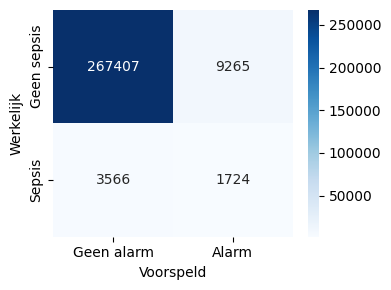

A – FE binary     0.1203
B – FE reg        0.1372
C – raw binary    0.1191
Blend A+B+C       0.1432
Name: utility, dtype: float64

In [20]:
blend_scores, blend_thr, blend_preds = apply_blend(study, preds_dict)

df_result = df_fe_val[['Patient_ID', 'SepsisLabel']].copy()
df_result['SepsisLabel_pred'] = blend_preds
final_utility = utility_score(df_result)

tp = int(((blend_preds == 1) & (y_fe_val.values == 1)).sum())
fp = int(((blend_preds == 1) & (y_fe_val.values == 0)).sum())
fn = int(((blend_preds == 0) & (y_fe_val.values == 1)).sum())
tn = int(((blend_preds == 0) & (y_fe_val.values == 0)).sum())

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Geen alarm', 'Alarm'],
            yticklabels=['Geen sepsis', 'Sepsis'], ax=ax)
ax.set_xlabel('Voorspeld')
ax.set_ylabel('Werkelijk')
plt.tight_layout()
plt.show()

pd.Series(
    {'A – FE binary': u_a, 'B – FE reg': u_b, 'C – raw binary': u_c, 'Blend A+B+C': final_utility},
    name='utility'
).round(4)

## 5. Evaluation

### Modelresultaten
De confusion matrix hierboven toont de verdeling van correcte en incorrecte voorspellingen op de validatieset. De Utility Score is berekend conform de aangeleverde aangepaste PhysioNet Challenge 2019-formule (`evaluation.py`).

### Bias-analyse 
We onderzoeken of het model gelijkwaardig presteert voor alle patiënten.  

We verdelen alle patienten in subgroepen. Dit zijn de groepen:
geslacht (man / vrouw) en leeftijdsgroep (jong <30 / jong-volwassen 30–50 / middel 50–70 / oud 70–80 / zeer oud >80 jaar).  

Voor elke groep berekenen we de utility score, sensitivity en specicifity.

In [44]:
# Demografische info per patiënt ophalen uit de validatieset
patienten_demo = df_fe_val.groupby('Patient_ID').agg(
    Geslacht=('Gender', 'first'),
    Leeftijd=('Age', 'first'),
).reset_index()
patienten_demo['Geslacht'] = patienten_demo['Geslacht'].map({0: 'Vrouw', 1: 'Man'})
patienten_demo['Leeftijdsgroep'] = pd.cut(
    patienten_demo['Leeftijd'],
    bins=[0, 30, 50, 70, 80, 200],
    labels=['Jong (<30)', 'Volwassen (30–50)', 'Middel (50–70)', 'Oud (70–80)', 'Zeer oud (>80)']
)

# Voorspellingen samenvoegen met demografie
df_bias = df_result.merge(patienten_demo, on='Patient_ID')

# Metrics berekenen per subgroep
def metrics_per_groep(df_sub):
    u = utility_score(df_sub)
    tp = int(((df_sub['SepsisLabel_pred'] == 1) & (df_sub['SepsisLabel'] == 1)).sum())
    fn = int(((df_sub['SepsisLabel_pred'] == 0) & (df_sub['SepsisLabel'] == 1)).sum())
    fp = int(((df_sub['SepsisLabel_pred'] == 1) & (df_sub['SepsisLabel'] == 0)).sum())
    tn = int(((df_sub['SepsisLabel_pred'] == 0) & (df_sub['SepsisLabel'] == 0)).sum())
    sensitiviteit = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificiteit = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return pd.Series({
        'Utility Score': round(u, 3),
        'Sensitiviteit': round(sensitiviteit, 3),
        'Specificiteit': round(specificiteit, 3),
    })

tabel_geslacht = df_bias.groupby('Geslacht').apply(metrics_per_groep)
tabel_leeftijd = df_bias.groupby('Leeftijdsgroep', observed=True).apply(metrics_per_groep)

#### Resultaten per geslacht

In [45]:
tabel_geslacht

,Utility Score,Sensitiviteit,Specificiteit
Geslacht,,,
Man,0.140,0.332,0.962
Vrouw,0.147,0.317,0.972


#### Resultaten per leeftijdsgroep

In [46]:
tabel_leeftijd

,Utility Score,Sensitiviteit,Specificiteit
Leeftijdsgroep,,,
Jong (<30),0.054,0.360,0.950
Volwassen (30–50),0.148,0.288,0.974
Middel (50–70),0.185,0.346,0.968
Oud (70–80),0.105,0.333,0.960
Zeer oud (>80),0.058,0.272,0.969


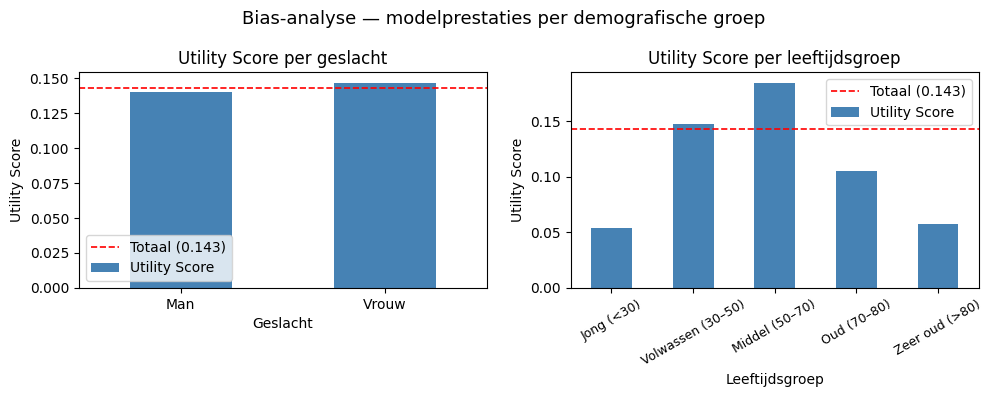

In [ ]:
# Visualisatie: Utility Score per subgroep 
fig, assen = plt.subplots(1, 2, figsize=(10, 4))

# Geslacht
tabel_geslacht['Utility Score'].plot(kind='bar', ax=assen[0], color='steelblue', rot=0)
assen[0].set_title('Utility Score per geslacht')
assen[0].set_ylabel('Utility Score')
assen[0].axhline(final_utility, color='red', linestyle='--', linewidth=1.2,
                 label=f'Totaal ({final_utility:.3f})')
assen[0].legend()

# Leeftijdsgroep
tabel_leeftijd['Utility Score'].plot(kind='bar', ax=assen[1], color='steelblue', rot=30)
assen[1].tick_params(axis='x', labelsize=9)
assen[1].set_title('Utility Score per leeftijdsgroep')
assen[1].set_ylabel('Utility Score')
assen[1].axhline(final_utility, color='red', linestyle='--', linewidth=1.2,
                 label=f'Totaal ({final_utility:.3f})')
assen[1].legend()

plt.suptitle('Bias-analyse — modelprestaties per demografische groep', fontsize=13)
plt.tight_layout()
plt.show()

### Conclusie bias-analyse



**Geslacht:**

Het model presteert bijna gelijkwaardig voor mannen en vrouwen. Het verschil in de utility score is minimaal (0.140 vs 147 utility score in het voordeel van vrouwen). Vrouwen scoren hoger un de specicifity (0.972 vs 0.962), terwijl de sensitivity lager ligt voor vrouwen (0.317 vs 0.332 voor mannen). 

Er is een oververtegenwoordiging van mannen in de traindata, ongeveer 56% man. Dit is een positief resultaat omdat de scheve geslachtsverdeling de prestaties van het model voor vrouwen niet meetbaar heeft benadeeld.

Op basis van geslacht kan het model als eerlijk worden beschouwd.

**Leeftijd:** 

Tussen verschillende leeftijdsgroepen zijn de prestatieverschillen groter. De middelste leeftijdsgroep (50-70 jaar) behaalt de hoogste utility score van 0.185, terwijl de jongste groep (<30 jaar) en de oudste groep (>80 jaar) het laagst scoren met elk 0.054 en 0.058. Dit is ruim onder het totaalgemiddelde van 0.143. De groepen Volwassenenen (30–50), Oud (70–80) zitten er tussenin met scores van 0.148 en 0.105. De sensitiviteit verschilt weinig tussen de groepen. Die zit tussen de 0.272-0.360. Maar de lagere Utility Score voor de jongste en oudste patiënten is zorgwekkend. Het model slaat voor deze groepen vaker te laat of op het verkeerde moment alarm.

Een mogelijke verklaring hiervoor is dat sepsis bij oudere patienten anders presenteert. Oudere patienten hebben vaak ook andere gezondheidsklachten waardoor de signalen van sepsis er niet tussenuit springen.

**Beoordeling van bias-analyse:**

Het model is redelijk eerlijk als het over geslacht gaat, maar laat een systematisch prestatienadeel zien voor patienten ouder dan 70 jaar. Dit is heel revelant voor de inzet in een ziekenhuis als Isala, waar de IC-populatie overwegend oud is. Bij toepassing in de praktijk zou de drempelwaarde voor deze groep apart gekalibreert worden, of aanvullende kenmerken toevoegen die sepsis bij oudere patienten beter karakteriseren. Als die niet wordt gedaan moet het zorgpersoneel er bewust van zijn dat het model voor oudere patienten een lagere betrouwbaarheid heeft.

## 6. Deployment

- **Hoe wordt het model ingezet?** ...
- **Vervolgstappen / aanbevelingen:** ...


## Voorspellingen testset pipeline
Voor de predictions.csv op 100% van de training set.
We trainen alle drie modellen opnieuw op 100% van de traindata zonder validatieset. Het aantal boosting-rondes komt van de early stopping uit modeling. De blend-gewichten en drempelwaarde komen uit de Optuna-studie en worden ongewijzigd toegepast op de testdata. Ook de hyperparameters zijn van tevoren getuned.

In [25]:
# Volledige traindata (geen val-split)
X_full_fe  = train_data_fe[FE_FEATURE_COLS]
y_full_fe  = train_data_fe['SepsisLabel']
X_full_raw = train_data[RAW_FEATURE_COLS]
y_full_raw = train_data['SepsisLabel']
y_util_full = compute_utility_labels(train_data_fe)

params_bin = dict(
    objective='binary', metric='auc', boosting_type='gbdt',
    learning_rate=0.03, num_leaves=63, max_depth=8,
    min_child_samples=80, scale_pos_weight=8,
    subsample=0.7, subsample_freq=1, colsample_bytree=0.6,
    reg_alpha=0.5, reg_lambda=2.0, min_gain_to_split=0.01,
    verbose=-1, n_jobs=-1, seed=42,
)

# Model A binary op FE-data
final_a = lgb.train(
    params_bin, lgb.Dataset(X_full_fe, label=y_full_fe),
    num_boost_round=model_a.best_iteration,
)

# Model B utility regressie op FE-data
sw_full = np.where(np.asarray(y_util_full) > 0, 10.0, 1.0)
final_b = LGBMRegressor(
    n_estimators=model_b.best_iteration_, learning_rate=0.03,
    num_leaves=63, max_depth=8, min_child_samples=80,
    subsample=0.7, subsample_freq=1, colsample_bytree=0.6,
    reg_alpha=0.5, reg_lambda=2.0, n_jobs=-1, random_state=42, verbose=-1,
).fit(X_full_fe, y_util_full, sample_weight=sw_full)

# Model C binary op ruwe data
final_c = lgb.train(
    params_bin, lgb.Dataset(X_full_raw, label=y_full_raw),
    num_boost_round=model_c.best_iteration,
)


In [26]:
# Voorspellingen op testdata
scores_test_a = final_a.predict(test_data_fe[FE_FEATURE_COLS])
scores_test_b = final_b.predict(test_data_fe[FE_FEATURE_COLS])
scores_test_c = final_c.predict(test_data[RAW_FEATURE_COLS])

preds_test_dict = {
    'fe_binary':  scores_test_a,
    'fe_reg':     scores_test_b,
    'raw_binary': scores_test_c,
}

# Blend-gewichten en drempelwaarde uit Optuna (ongewijzigd)
_, _, test_binary = apply_blend(study, preds_test_dict)

predictions = test_data[['Patient_ID']].copy()
predictions['SepsisLabel'] = test_binary
predictions.to_csv('predictions.csv', index=False)

print(f"predictions.csv  ·  {int(test_binary.sum()):,} alarmen / {len(test_binary):,} rijen  ({test_binary.mean()*100:.1f}%)")

predictions.csv  ·  777 alarmen / 152,908 rijen  (0.5%)


## Bronnenlijst

[Luijks, M., et al. (2024). Societal costs of sepsis in the Netherlands. BMC Critical Care, 22 januari 2024. [2]](https://pubmed.ncbi.nlm.nih.gov/38254226/)

[Rudd, K.E., et al. (2020). Global, regional, and national sepsis incidence and mortality, 1990–2017. The Lancet, 18 januari 2020. [4]](https://pubmed.ncbi.nlm.nih.gov/31954465/)

[https://artificialintelligenceact.eu/the-act/ [6]](https://artificialintelligenceact.eu/the-act/)